In [2]:
!pip install torchao --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 49.4 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import sys
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/image_realness_project")
sys.path.insert(0, str(PROJECT))

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [5]:
import torch
device = torch.cuda if torch.cuda.is_available() else "CPU only"
print(device)

<module 'torch.cuda' from '/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py'>


In [6]:
# Cell 1 — Setup
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import subprocess

PROJECT = Path("/content/drive/MyDrive/image_realness_project")
sys.path.insert(0, str(PROJECT))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from core.models.joint_model import JointModel
from core.generation.sd_generator import load_sd_pipeline

joint_model = JointModel(use_pretrained_backbones=True).to(device)
state = torch.load(PROJECT / "checkpoints" / "JOINT_2024.pth", map_location=device)
joint_model.load_state_dict(state)
joint_model.eval()

pipe = load_sd_pipeline(project=PROJECT, device=device.type)
pipe.safety_checker = None
print("Ready")

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:01<00:00, 85.3MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 93.5MB/s]


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Ready


In [7]:
# Cell 2 — Define scorers for each LFM method
from scripts.generate_with_without_lfm import LFMScorer

scorer_none     = LFMScorer(joint_model, lfm_method="none").to(device).eval()
scorer_gaussian = LFMScorer(joint_model, lfm_method="gaussian").to(device).eval()
scorer_at       = LFMScorer(joint_model, lfm_method="at").to(device).eval()

def score_path(path, scorer):
    img = Image.open(path).convert("RGB")
    t = TF.to_tensor(img).unsqueeze(0).to(device).float()
    with torch.no_grad():
        return scorer(t).item()

In [8]:
image_paths = sorted((PROJECT / "outputs" / "large_scale_experiment").glob("prompt_*/no_guidance.png"))
print(f"Found {len(image_paths)} images")
print(image_paths[0])

Found 30 images
/content/drive/MyDrive/image_realness_project/outputs/large_scale_experiment/prompt_000/no_guidance.png


In [ ]:
# Cell 3 — PART 1: Score existing images three ways
rows = []
for p in image_paths[:10]:
    s_none     = score_path(p, scorer_none)
    s_gaussian = score_path(p, scorer_gaussian)
    s_at       = score_path(p, scorer_at)
    rows.append({
        "image": p.parent.name,
        "none": s_none, "gaussian": s_gaussian, "at": s_at,
        "gauss_vs_none": s_gaussian - s_none,
        "at_vs_none":    s_at - s_none,
        "at_vs_gauss":   s_at - s_gaussian,
    })
    print(f"{p.parent.name} | none={s_none:.4f} gauss={s_gaussian:.4f} at={s_at:.4f}")

df = pd.DataFrame(rows)
print("\nMean differences:")
print(df[["gauss_vs_none","at_vs_none","at_vs_gauss"]].mean())
df.to_csv(PROJECT / "outputs" / "lfm_score_comparison.csv", index=False)

prompt_000 | none=4.3325 gauss=4.1057 at=4.3495
prompt_001 | none=3.7267 gauss=3.6579 at=3.8131
prompt_002 | none=4.0007 gauss=4.0312 at=4.0252
prompt_003 | none=3.8686 gauss=3.4291 at=3.9034
prompt_004 | none=3.2449 gauss=2.5610 at=3.4469
prompt_005 | none=3.9097 gauss=3.3428 at=3.9270
prompt_006 | none=3.6160 gauss=3.2984 at=3.5958
prompt_007 | none=3.7937 gauss=3.3163 at=3.8395
prompt_008 | none=4.1662 gauss=3.3795 at=4.2829
prompt_009 | none=4.2359 gauss=3.1775 at=3.9675

Mean differences:
gauss_vs_none   -0.459539
at_vs_none       0.025591
at_vs_gauss      0.485129
dtype: float64


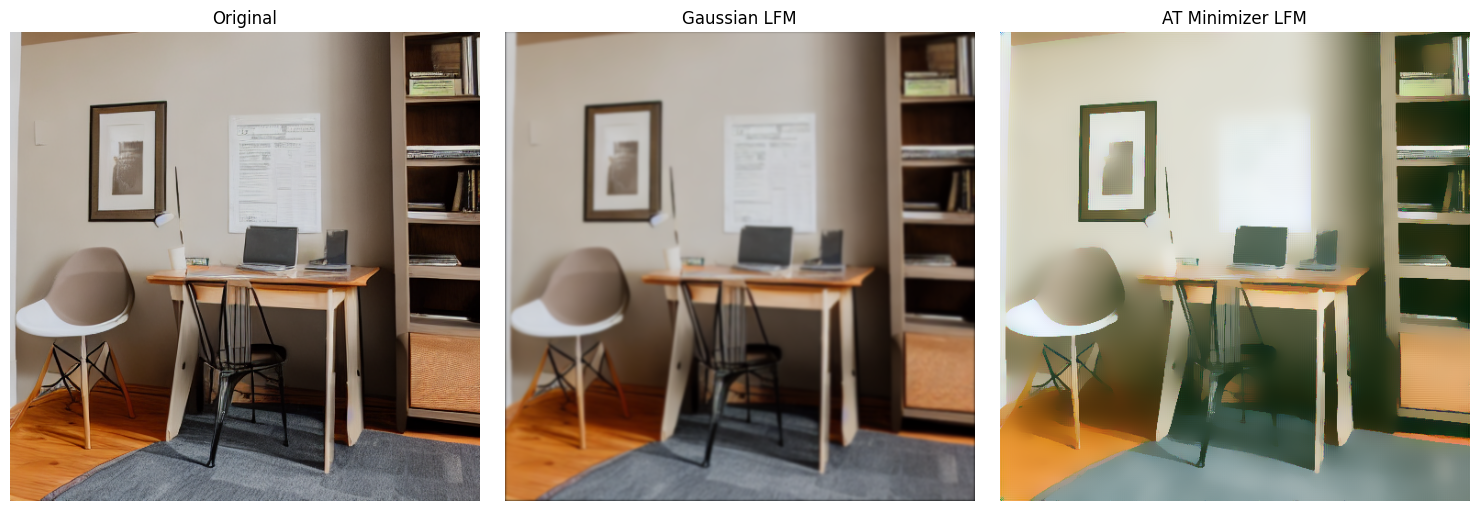

In [ ]:
# Cell 4 — PART 1: Visualize LFM outputs visually
from scripts.generate_with_without_lfm import ATMinimizer, _gaussian_kernel_2d

at_min = ATMinimizer().to(device)

img = Image.open(image_paths[0]).convert("RGB")
x = TF.to_tensor(img).unsqueeze(0).to(device).float()

with torch.no_grad():
    # gaussian
    kernel = _gaussian_kernel_2d(11, 1.4).unsqueeze(0).unsqueeze(0).repeat(3,1,1,1).to(device)
    lfm_gauss = F.conv2d(x, kernel, padding=5, groups=3)
    # at
    channels = torch.unbind(x, dim=1)
    lfm_at = torch.cat([at_min(ch.unsqueeze(1)) for ch in channels], dim=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(lfm_gauss[0].cpu().permute(1,2,0).clamp(0,1).numpy())
axes[1].set_title("Gaussian LFM"); axes[1].axis("off")
axes[2].imshow(lfm_at[0].cpu().permute(1,2,0).clamp(0,1).numpy())
axes[2].set_title("AT Minimizer LFM"); axes[2].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
# Cell 5 — PART 2: Run inference guidance with each LFM method
PROMPT = "a golden retriever in a sunlit meadow"
SEED   = 42
LFM_DIR = PROJECT / "outputs" / "lfm_guidance_comparison"

for method in ["none", "gaussian", "at"]:
    out_dir = LFM_DIR / method
    out_dir.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "python",
        str(PROJECT / "scripts" / "generate_with_without_lfm.py"),
        "--project",             str(PROJECT),
        "--prompt",              PROMPT,
        "--lfm-method",          method,
        "--output-dir",          str(out_dir),
        "--num-inference-steps", "30",
        "--guidance-scale",      "7.5",
        "--rationality-weight",  "0.5",
        "--guidance-last-steps", "10",
        "--seed",                str(SEED),
    ])
    print(f"[{method}] done")

[none] done
[gaussian] done
[at] done


  0%|          | 0/30 [00:00<?, ?it/s]

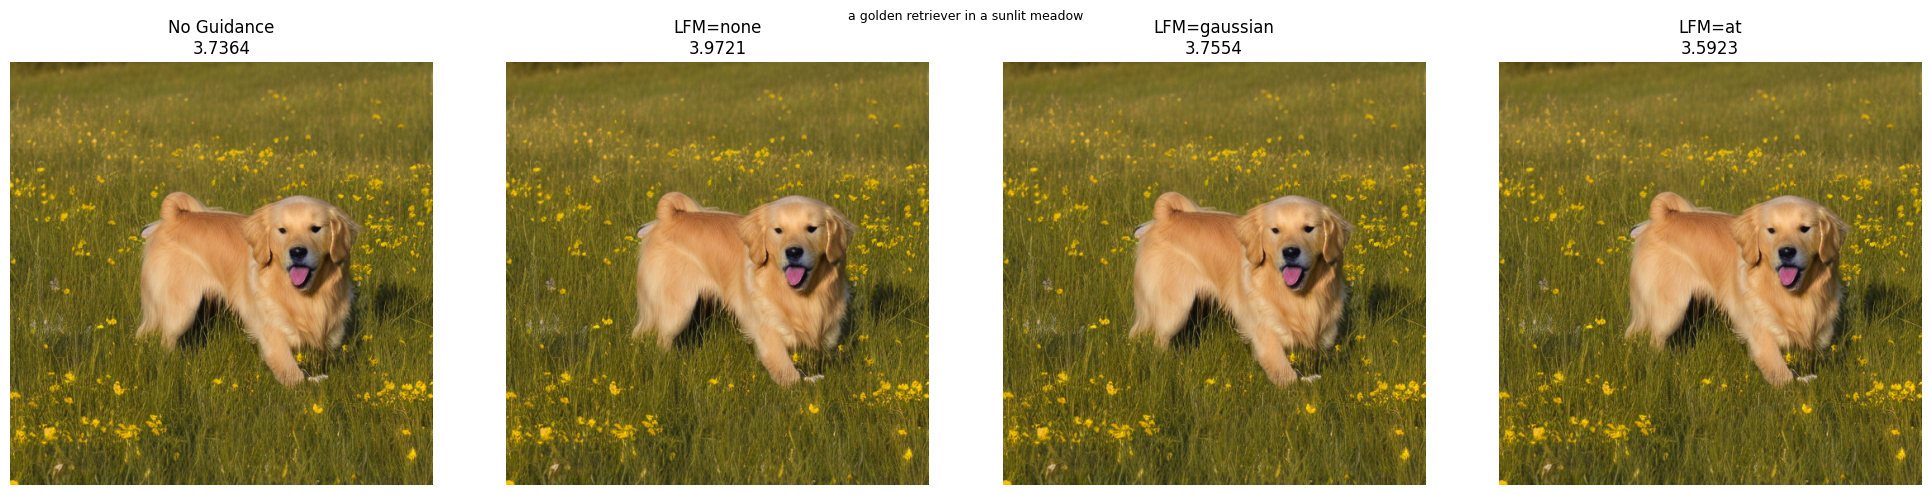

In [ ]:
# Cell 6 — PART 2: Compare guided images visually with scores
methods = ["none", "gaussian", "at"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# no guidance baseline
from core.generation.sd_generator import generate_image
no_guid_path = LFM_DIR / "no_guidance.png"
generate_image(pipe=pipe, prompt=PROMPT, output_path=no_guid_path,
               guidance_scale=7.5, num_inference_steps=30, seed=SEED)
axes[0].imshow(Image.open(no_guid_path))
axes[0].set_title(f"No Guidance\n{score_path(no_guid_path, scorer_gaussian):.4f}")
axes[0].axis("off")

for ax, method, scorer in zip(axes[1:], methods,
                               [scorer_none, scorer_gaussian, scorer_at]):
    p = LFM_DIR / method / "guided_000.png"
    s = score_path(p, scorer)
    ax.imshow(Image.open(p))
    ax.set_title(f"LFM={method}\n{s:.4f}")
    ax.axis("off")

plt.suptitle(PROMPT, fontsize=9)
plt.tight_layout(); plt.show()

In [9]:
import json

# check what's available in AGIN folder
import os
print(os.listdir(PROJECT / "external" / "AGIN"))

['MSCOCO_prompt.xlsx', '.DS_Store', 'image_attribute_feature.py', 'README.md', 'keyword_prompt.xlsx', 'intro.jpg', 'DrawBench_prompt.xlsx', '.git', 'JOINT']


In [10]:
import pandas as pd

mscoco   = pd.read_excel(PROJECT / "external" / "AGIN" / "MSCOCO_prompt.xlsx")
keyword  = pd.read_excel(PROJECT / "external" / "AGIN" / "keyword_prompt.xlsx")
drawbench = pd.read_excel(PROJECT / "external" / "AGIN" / "DrawBench_prompt.xlsx")

print(mscoco.columns.tolist())
print(keyword.columns.tolist())
print(drawbench.columns.tolist())

['id', 'coco_prompt']
['keyword', 'prompt1', 'prompt2', 'prompt3', 'prompt4', 'prompt5', 'prompt6', 'prompt7', 'prompt8', 'prompt9', 'prompt10', 'Unnamed: 11', 'note']
['id', 'Drawbench_prompt', 'Category']


In [11]:
# combine all prompts
mscoco_prompts    = mscoco["coco_prompt"].dropna().tolist()
keyword_prompts   = keyword[["prompt1","prompt2","prompt3","prompt4","prompt5",
                              "prompt6","prompt7","prompt8","prompt9","prompt10"]]\
                    .values.flatten().tolist()
keyword_prompts   = [p for p in keyword_prompts if isinstance(p, str)]
drawbench_prompts = drawbench["Drawbench_prompt"].dropna().tolist()

all_prompts = mscoco_prompts + keyword_prompts + drawbench_prompts
print(f"MSCOCO: {len(mscoco_prompts)}, Keyword: {len(keyword_prompts)}, DrawBench: {len(drawbench_prompts)}")
print(f"Total: {len(all_prompts)}")

MSCOCO: 600, Keyword: 200, DrawBench: 128
Total: 928


In [ ]:
import random, gc

PROMPTS = random.sample(all_prompts, 20)
METHODS = ["none", "gaussian", "at"]
WEIGHTS = [0.5, 1.0, 2.0]
SEED    = 42

# Step 1 — generate all baselines first
for prompt in PROMPTS:
    slug = prompt[:30].replace(" ", "_").replace(",","").replace(".","")
    no_guid_path = PROJECT / "outputs" / "lfm_grid" / slug / "no_guidance.png"
    no_guid_path.parent.mkdir(parents=True, exist_ok=True)
    if not no_guid_path.exists():
        generate_image(pipe=pipe, prompt=prompt, output_path=no_guid_path,
                       guidance_scale=7.5, num_inference_steps=30, seed=SEED)
    print(f"Base done: {slug[:30]}")

# Step 2 — free memory
del pipe
gc.collect()
torch.cuda.empty_cache()
print(f"GPU free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

# Step 3 — run guided
rows = []
for prompt in PROMPTS:
    slug = prompt[:30].replace(" ", "_").replace(",","").replace(".","")
    no_guid_path = PROJECT / "outputs" / "lfm_grid" / slug / "no_guidance.png"
    s_base = score_path(no_guid_path, scorer_gaussian)
    print(f"\n[{slug[:30]}] base={s_base:.4f}")

    for method in METHODS:
        for rw in WEIGHTS:
            out_dir = PROJECT / "outputs" / "lfm_grid" / slug / f"{method}_rw{rw}"
            out_dir.mkdir(parents=True, exist_ok=True)

            # skip if already generated
            if (out_dir / "guided_000.png").exists():
                s = score_path(out_dir / "guided_000.png", scorer_gaussian)
            else:
                env_vars = {"PYTORCH_CUDA_ALLOC_CONF": "expandable_segments:True"}
                import os
                env = {**os.environ, **env_vars}
                result = subprocess.run([
                    "python", str(PROJECT / "scripts" / "generate_with_without_lfm.py"),
                    "--project",             str(PROJECT),
                    "--prompt",              prompt,
                    "--lfm-method",          method,
                    "--output-dir",          str(out_dir),
                    "--rationality-weight",  str(rw),
                    "--guidance-last-steps", "10",
                    "--num-inference-steps", "30",
                    "--guidance-scale",      "7.5",
                    "--seed",                str(SEED),
                ], env=env)

                if not (out_dir / "guided_000.png").exists():
                    print(f"  FAILED: {method} rw={rw} — skipping")
                    continue
                s = score_path(out_dir / "guided_000.png", scorer_gaussian)

            rows.append({
                "prompt": prompt, "method": method, "rw": rw,
                "base_score": s_base, "guided_score": s,
                "diff": s - s_base
            })
            print(f"  {method} rw={rw} | guided={s:.4f} diff={s-s_base:+.4f}")

results = pd.DataFrame(rows)
results.to_csv(PROJECT / "outputs" / "lfm_grid_results.csv", index=False)

print("\n--- Mean diff by method ---")
print(results.groupby("method")["diff"].mean())
print("\n--- Mean diff by weight ---")
print(results.groupby("rw")["diff"].mean())
print("\n--- Mean diff by method+weight ---")
print(results.groupby(["method","rw"])["diff"].mean())

  0%|          | 0/30 [00:00<?, ?it/s]

Base done: A_herd_of_black_sheep_grazing_


  0%|          | 0/30 [00:00<?, ?it/s]

Base done: Large_junkyard_with_boats_on_o


  0%|          | 0/30 [00:00<?, ?it/s]

...

Base done: A_red_colored_banana


  0%|          | 0/30 [00:00<?, ?it/s]

Base done: A_person_cutting_into_a_doughn


  0%|          | 0/30 [00:00<?, ?it/s]

Base done: A_storefront_with_'Text_to_Ima
GPU free: 11.18 GB

[A_herd_of_black_sheep_grazing_] base=3.4647
  none rw=0.5 | guided=3.4667 diff=+0.0021
  none rw=1.0 | guided=3.4680 diff=+0.0033
  none rw=2.0 | guided=3.4704 diff=+0.0057
  gaussian rw=0.5 | guided=3.4762 diff=+0.0115
  gaussian rw=1.0 | guided=3.4908 diff=+0.0261
  gaussian rw=2.0 | guided=3.5150 diff=+0.0504
  at rw=0.5 | guided=3.4654 diff=+0.0008
  at rw=1.0 | guided=3.4659 diff=+0.0013
  at rw=2.0 | guided=3.4644 diff=-0.0003

[Large_junkyard_with_boats_on_o] base=2.6325
  none rw=0.5 | guided=2.6354 diff=+0.0029
  none rw=1.0 | guided=2.6370 diff=+0.0046
  none rw=2.0 | guided=2.6433 diff=+0.0109
  gaussian rw=0.5 | guided=2.6722 diff=+0.0398
  gaussian rw=1.0 | guided=2.7128 diff=+0.0804
  gaussian rw=2.0 | guided=2.8043 diff=+0.1718
  at rw=0.5 | guided=2.6309 diff=-0.0015
  at rw=1.0 | guided=2.6309 diff=-0.0016
  at rw=2.0 | guided=2.6330 diff=+0.0005

[A_skateboarded_is_going_up_a_j] base=3.0985
  none rw=0.5 |

In [12]:
# Cell 7 — PART 3: LoRA finetuning with none and at scorers
from diffusers import StableDiffusionPipeline, DDIMScheduler
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW
import random, gc, torch.nn.functional as F

LORA_LFM_DIR = PROJECT / "checkpoints" / "lora_lfm"
LORA_LFM_DIR.mkdir(parents=True, exist_ok=True)

df_prompts = pd.read_excel(PROJECT / "external" / "AGIN" / "MSCOCO_prompt.xlsx")
prompts = df_prompts["coco_prompt"].dropna().tolist()[:30]

for lfm_method in ["none", "at"]:
    print(f"\n{'='*40}\nTraining LoRA with LFM={lfm_method}\n{'='*40}")

    pipe_train = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
    )
    pipe_train.scheduler = DDIMScheduler.from_config(pipe_train.scheduler.config)
    pipe_train.safety_checker = None
    pipe_train = pipe_train.to(device)

    lora_config = LoraConfig(r=16, lora_alpha=32,
                             init_lora_weights="gaussian",
                             target_modules=["to_k","to_q","to_v","to_out.0"])
    pipe_train.unet = get_peft_model(pipe_train.unet, lora_config)

    train_scorer = LFMScorer(joint_model, lfm_method=lfm_method).to(device).eval()

    trainable = [p for p in pipe_train.unet.parameters() if p.requires_grad]
    for p in trainable: p.data = p.data.to(torch.float32)
    optimizer = AdamW(trainable, lr=1e-5)
    scaler = torch.amp.GradScaler("cuda")

    pipe_train.vae.to(torch.float32)
    pipe_train.unet.train()
    pipe_train.scheduler.set_timesteps(20)

    for step in range(100):
        prompt = random.choice(prompts)
        text_inputs = pipe_train.tokenizer(
            prompt, padding="max_length",
            max_length=pipe_train.tokenizer.model_max_length,
            truncation=True, return_tensors="pt"
        )
        with torch.no_grad():
            text_embeds = pipe_train.text_encoder(
                text_inputs.input_ids.to(device)
            )[0].detach().expand(2, -1, -1)

            latents = torch.randn((2,4,64,64), device=device, dtype=torch.float16)
            for t in pipe_train.scheduler.timesteps:
                noise_pred = pipe_train.unet(latents, t, encoder_hidden_states=text_embeds).sample
                latents = pipe_train.scheduler.step(noise_pred, t, latents).prev_sample

            decoded = pipe_train.vae.decode(
                latents.to(torch.float32) / pipe_train.vae.config.scaling_factor
            ).sample
            decoded = torch.clamp((decoded / 2 + 0.5), 0, 1)
            if torch.isnan(decoded).any(): continue

            scores = train_scorer(decoded).squeeze()
            best_idx = torch.argmax(scores)
            best_latent = latents[best_idx].unsqueeze(0)

        optimizer.zero_grad()
        max_t = pipe_train.scheduler.config.num_train_timesteps
        train_t = torch.randint(0, max_t, (1,), device=device).long()
        noise = torch.randn_like(best_latent)
        noisy = pipe_train.scheduler.add_noise(best_latent, noise, train_t)

        with torch.amp.autocast("cuda"):
            noise_pred = pipe_train.unet(
                noisy, train_t,
                encoder_hidden_states=text_embeds[:1]
            ).sample
            loss = F.mse_loss(noise_pred.float(), noise.float())

        if torch.isnan(loss): continue
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(trainable, 1.0)
        scaler.step(optimizer); scaler.update()

        del latents, decoded, noise_pred, loss
        gc.collect(); torch.cuda.empty_cache()

        if step % 20 == 0:
            print(f"  step {step}/100")

    save_path = LORA_LFM_DIR / f"lora_{lfm_method}"
    pipe_train.unet.save_pretrained(str(save_path))
    print(f"Saved: {save_path}")

    del pipe_train, train_scorer
    gc.collect(); torch.cuda.empty_cache()


Training LoRA with LFM=none


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

  step 0/100
  step 20/100
  step 40/100
  step 60/100
  step 80/100
Saved: /content/drive/MyDrive/image_realness_project/checkpoints/lora_lfm/lora_none

Training LoRA with LFM=at


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  step 0/100
  step 20/100
  step 40/100
  step 60/100
  step 80/100
Saved: /content/drive/MyDrive/image_realness_project/checkpoints/lora_lfm/lora_at


In [13]:
def score_path_pil(img, scorer):
    t = TF.to_tensor(img).unsqueeze(0).to(device).float()
    with torch.no_grad():
        return scorer(t).item()

In [14]:
import pandas as pd
df_prompts = pd.read_excel(PROJECT / "external" / "AGIN" / "MSCOCO_prompt.xlsx")
prompts = df_prompts["coco_prompt"].dropna().tolist()[:30]
LORA_LFM_DIR = PROJECT / "checkpoints" / "lora_lfm"

In [16]:
# Cell 8 — PART 3: Compare base vs lora_none vs lora_at
from peft import PeftModel
from diffusers import StableDiffusionPipeline, DDIMScheduler
import torch
TEST_PROMPTS = prompts[:5]

pipe_base = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
).to(device)
pipe_base.safety_checker = None

pipes = {"base": pipe_base}

from peft import PeftModel

LORA_GAUSSIAN_DIR = PROJECT / "checkpoints" / "lora" / "epoch_4"

pipe_gaussian = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
).to(device)
pipe_gaussian.safety_checker = None
pipe_gaussian.unet = PeftModel.from_pretrained(
    pipe_gaussian.unet, str(LORA_GAUSSIAN_DIR), is_trainable=False
)
pipes["lora_gaussian"] = pipe_gaussian


for method in ["none", "at"]:
    p = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
    ).to(device)
    p.safety_checker = None
    p.unet = PeftModel.from_pretrained(p.unet, str(LORA_LFM_DIR / f"lora_{method}"),
                                        is_trainable=False)
    pipes[f"lora_{method}"] = p

def gen_image(pipe, prompt, seed=42):
    g = torch.Generator(device=device).manual_seed(seed)
    with torch.no_grad():
        return pipe(prompt, num_inference_steps=50,
                    guidance_scale=7.5, generator=g).images[0]

for prompt in TEST_PROMPTS:
    n = len(pipes)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    for ax, (name, pipe_) in zip(axes, pipes.items()):
        img = gen_image(pipe_, prompt)
        s = score_path_pil(img, scorer_gaussian)
        ax.imshow(img)
        ax.set_title(f"{name}\n{s:.4f}", fontsize=9)
        ax.axis("off")
    plt.suptitle(prompt[:60], fontsize=9)
    plt.tight_layout(); plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [17]:
COMPARE_DIR = PROJECT / "outputs" / "lora_lfm_comparison"
COMPARE_DIR.mkdir(exist_ok=True)

for i, prompt in enumerate(TEST_PROMPTS):
    for name, pipe_ in pipes.items():
        img = gen_image(pipe_, prompt)
        img.save(COMPARE_DIR / f"prompt_{i:02d}_{name}.png")
    print(f"Saved prompt {i}")

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Saved prompt 0


...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Saved prompt 4


In [18]:
import random

# Use AGIN prompts for better diversity
TEST_PROMPTS_LARGE = random.sample(all_prompts, 15)

COMPARE_DIR = PROJECT / "outputs" / "lora_lfm_comparison_large"
COMPARE_DIR.mkdir(exist_ok=True)

rows = []

for i, prompt in enumerate(TEST_PROMPTS_LARGE):
    print(f"\n[{i+1}/{len(TEST_PROMPTS_LARGE)}] {prompt[:50]}")
    n = len(pipes)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

    for ax, (name, pipe_) in zip(axes, pipes.items()):
        img = gen_image(pipe_, prompt, seed=42)
        s = score_path_pil(img, scorer_gaussian)
        ax.imshow(img)
        ax.set_title(f"{name}\n{s:.4f}", fontsize=9)
        ax.axis("off")
        img.save(COMPARE_DIR / f"prompt_{i:02d}_{name}.png")
        rows.append({
            "prompt": prompt, "model": name,
            "score": s
        })

    plt.suptitle(prompt[:60], fontsize=9)
    plt.tight_layout()
    plt.show()

# summary table
df = pd.DataFrame(rows)
summary = df.groupby("model")["score"].agg(["mean","std","min","max"])
print("\n--- Score summary by model ---")
print(summary.to_string())
df.to_csv(COMPARE_DIR / "scores.csv", index=False)

Output hidden; open in https://colab.research.google.com to view.